## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import sklearn

import warnings
warnings.filterwarnings('ignore')

In [323]:
data = pd.read_csv(r'D:\python_main\training_env\Introduction-to-Machine-learning-and-Statistics\data\penguins_data.csv')
display(data.head(10))
print(data.shape[0])

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


344


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [324]:
checker: pd.Series = data.isnull().sum()

if checker.any():
    print(f'Пропущенные значения есть. Они в колонках {checker[checker != 0].index.tolist()}')
    data.dropna(how='any', inplace=True)
    print('Всё удалили', data.shape[0])
else:
    print('Пропущенных значений нет')

Пропущенные значения есть. Они в колонках ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)']
Всё удалили 325


In [325]:
if len(data.select_dtypes(include='object')) != 0:
    print(f'Категориальные признаки есть, вот они: {data.select_dtypes(include='object').columns}')

Категориальные признаки есть, вот они: Index(['Species', 'Island', 'Clutch Completion', 'Sex'], dtype='object')


Видим, что все категориальные признаки представляют собой категориальные номинальные данные, т.е. в них нет никакого порядка, поэтому будем использовать обычный OneHotEncoder для преобразования. В этих колонах не так много уникальных значений, поэтому мы не сильно расширим датасет. Целевую переменную не трогаем, т.к. в следующем пункте будем кодировать её через OrdinalEncoder

In [326]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

columns = [column for column in data.select_dtypes(include='object') if column != 'Species']

preprocessor = ColumnTransformer(transformers=[('ohe1', OneHotEncoder(drop='first', sparse_output=False), columns)], 
                                 remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
data = preprocessor.fit_transform(data)
data.head()

,Island_Dream,Island_Torgersen,Clutch Completion_Yes,Sex_FEMALE,Sex_MALE,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
0,1.0,0.0,1.0,0.0,1.0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594
1,1.0,0.0,1.0,1.0,0.0,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433
2,0.0,0.0,1.0,1.0,0.0,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829
3,1.0,0.0,1.0,1.0,0.0,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984
4,0.0,0.0,1.0,1.0,0.0,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [327]:
from sklearn.preprocessing import OrdinalEncoder

ode = OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']]).set_output(transform='pandas')
y = ode.fit_transform(data[['Species']]).astype('int64')
X = data.drop(columns=['Species'])


**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [328]:
from sklearn.model_selection import train_test_split

X_train_penguins, x_test_penguins, y_train_penguins, y_test_penguins = train_test_split(X, np.array(y['Species']), test_size=0.3, random_state=52, stratify=y)
X_train_penguins.shape[0], x_test_penguins.shape[0]

(227, 98)

Аргумент stratify важно использовать, потому что это гарантирует соблюдение баланса классов в обучающей и тестовой выборке. Ниже видим, что Chinstrap представлен меньше всего в датасете. Без использования stratify могло получиться так при разбиении, что этот класс полностью потерялся в одной из выборок.

In [329]:
y.value_counts(normalize=True)

Species
2          0.427692
1          0.366154
0          0.206154
Name: proportion, dtype: float64

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [330]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from collections import defaultdict

neighbors = [1, 3, 5, 10, 15, 25]
accuracy_slovar = defaultdict(list)
knn_classifiers = []

std = StandardScaler().set_output(transform='pandas').fit(X_train_penguins[['Flipper Length (mm)', 'Body Mass (g)']])
X_train_scaled_penguins = std.transform(X_train_penguins[['Flipper Length (mm)', 'Body Mass (g)']])
X_test_scaled_penguins = std.transform(x_test_penguins[['Flipper Length (mm)', 'Body Mass (g)']])

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled_penguins, y_train_penguins)
    knn_classifiers.append(knn)
    
    y_pred_train = knn.predict(X_train_scaled_penguins)
    accuracy_slovar['accuracy_train'].append(accuracy_score(y_train_penguins, y_pred_train))
    
    y_pred_test = knn.predict(X_test_scaled_penguins)
    accuracy_slovar['accuracy_test'].append(accuracy_score(y_test_penguins, y_pred_test))

print(f'NN\tTrain\tTest')
for index, k in enumerate(neighbors):
    print(f'{k}\t{round(accuracy_slovar['accuracy_train'][index], 3)}\t{round(accuracy_slovar["accuracy_test"][index], 3)}')

NN	Train	Test
1	0.96	0.806
3	0.841	0.786
5	0.833	0.786
10	0.806	0.837
15	0.811	0.837
25	0.806	0.816


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [331]:
# !pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [332]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

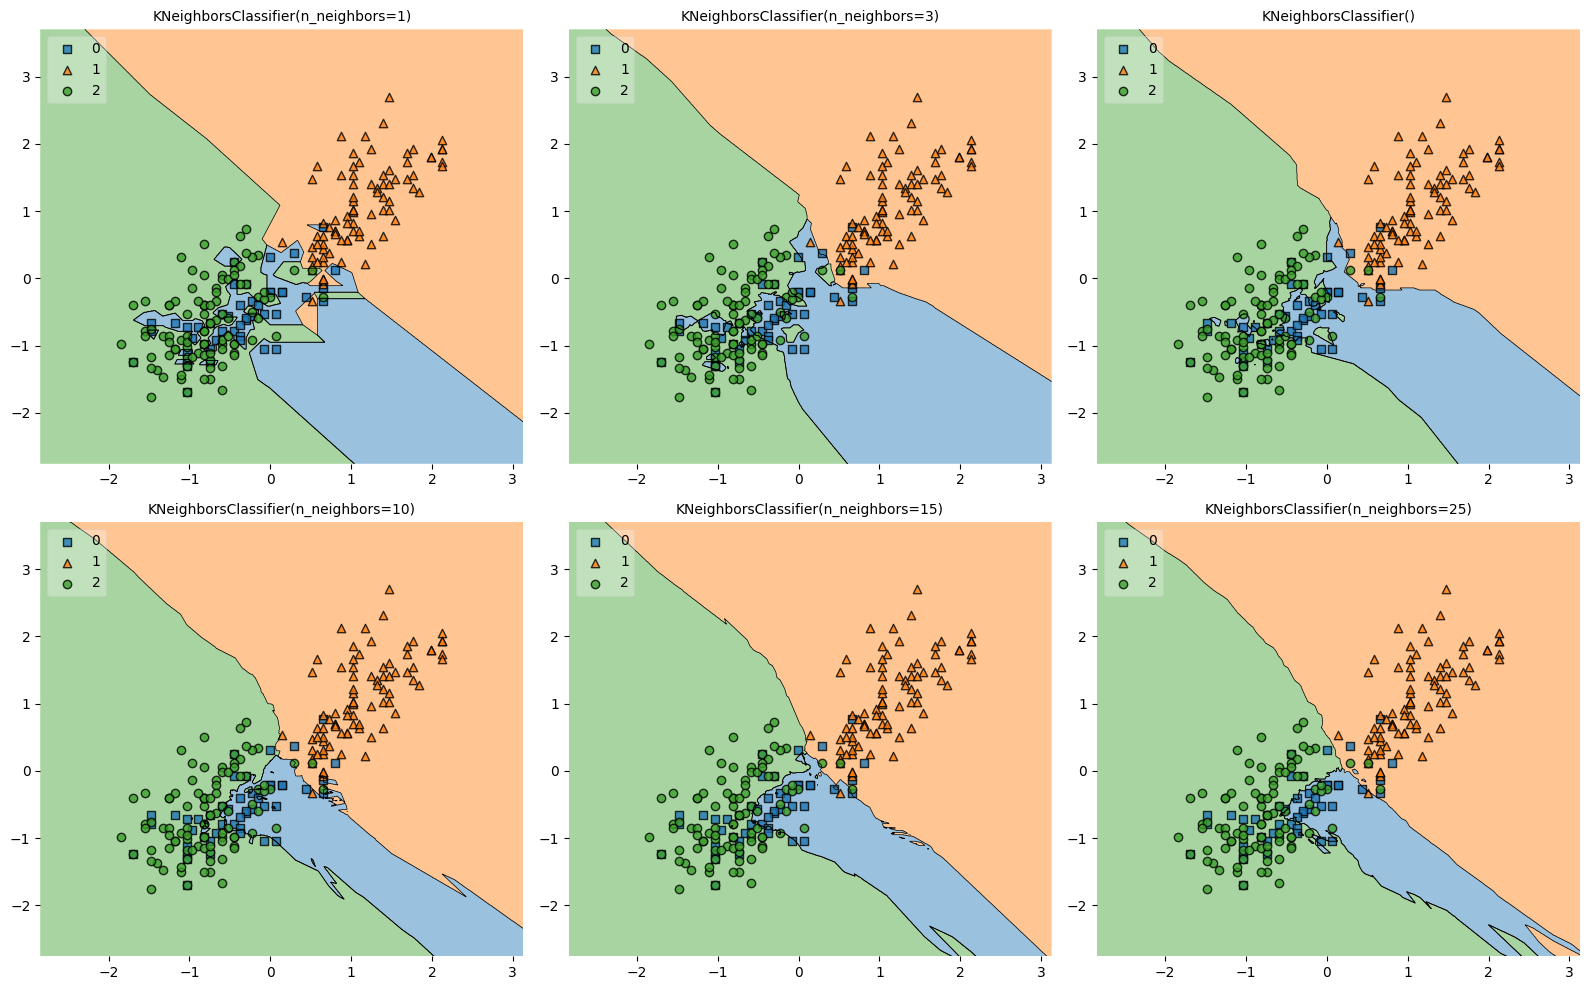

In [333]:
from mlxtend.plotting import plot_decision_regions

fig, ax = plt.subplots(2, 3, figsize=(16, 10))

for index, knn in enumerate(knn_classifiers):
    plot_decision_regions(X=np.array(X_train_scaled_penguins), y=y_train_penguins, clf=knn, legend=2, ax=ax[index // 3, index % 3])
    ax[index // 3, index % 3].set_title(knn, fontsize=10)
    
plt.tight_layout()
plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

На обучающей выборке оптимум всегда k=1, на тестовой у нас лучше всего отрабатыает k=15. Какова геометрия: при k до 5 видим, что у нас области классов рисуются очень разрозненно и обрывисто, т.к. одинокие объекты создают вокруг себя лишние зоны, что по итогу мешает классификатору норм работать на новых данных.

Самая песня при k=10 или k=15, видим, что ошибка там одинаковая и области рисуются красиво, нет разрывов, линии четкие. При увеличении k=25 будет становиться хуже, т.к. каждый объект начинает захыватыть все больше и больше объектов вокруг себя и так происходит для каждого объекта, т.е. они становятся менее отличимы друг от друга.

В итоге при маленьких k (1, 3, 5) мы жёстко переобучаемся: одиноко стояющим объектам не хватает соседей и они отрисовывают в качестве новой зоны тупо собственный класс. Ну а при больших k мы просто недообучаемся, там наоборот слишком много одинаковых соседей хватает каждый объект.

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

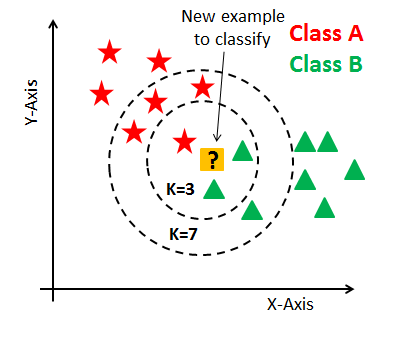

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [ ]:
import numpy as np
from collections import Counter
from typing import Union

class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):
      '''Обучение - тупо выборку запомнить и на том спасибо'''
      self.X_train = np.array(X)
      self.y_train = np.array(y) # запомнили обучающую выборку
      return self

    def predict(self, X: Union[np.array, pd.DataFrame]):
      if type(X) == pd.DataFrame:
        X = np.array(X.values)
      '''Обучаем по алгоритму: 
      1. Вычислили расстояние до всех объектов трейна
      2. Нашли к ближайших
      3. Чекнули самый популярный класс
      4. сказали что у нового объекта такой же'''
      distances: np.array = self.count_distance(self.X_train, X) # расстояния до всех объектов
      first_k_index = np.argsort(distances, axis=0)[:self.k] # первые индексы
      # print(distances)
      # print(first_k_index)
      first_k_y = self.y_train[first_k_index] # первые к ответов
      # print(first_k_y)
      top_classes = np.apply_along_axis(lambda x: Counter(x).most_common(1)[0][0], axis=0, arr=first_k_y)
      # print(top_classes)
      return top_classes

    def count_distance(self, x: Union[np.array, pd.DataFrame], y: Union[np.array, pd.DataFrame]):
      '''Метод для вычисления значения метрики между вдумя объектами. Всё надо перевести в нампай, иначе почему-то умирает на следующей таске'''
      x = np.array(x)
      y = np.array(y)
      x = x[:, np.newaxis, :] # бахнул из двумерной матрицы пачку матриц, получил штуку с тремя осями
      return np.linalg.norm(x-y, axis=2)

In [335]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [336]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [337]:
from collections import defaultdict
from sklearn.metrics import mean_squared_error

neighbors = [1, 3, 5, 10, 15, 25]
myknn_accuracy_slovar = defaultdict(list)

for k in neighbors:
    knn = KNN(k).fit(X_train_scaled_penguins, y_train_penguins)
    
    y_myknn_pred_train = knn.predict(X_train_scaled_penguins)
    myknn_accuracy_slovar['accuracy_train'].append(mean_squared_error(y_train_penguins, y_myknn_pred_train))
    
    y_myknn_pred_test = knn.predict(X_test_scaled_penguins)
    myknn_accuracy_slovar['accuracy_test'].append(mean_squared_error(y_test_penguins, y_myknn_pred_test))


print(f'NN\tTrain\tTest')
for index, k in enumerate(neighbors):
    print(f'{k}\t{round(myknn_accuracy_slovar['accuracy_train'][index], 3)}\t{round(myknn_accuracy_slovar["accuracy_test"][index], 3)}')

NN	Train	Test
1	0.163	0.918
3	0.52	0.827
5	0.537	0.796
10	0.621	0.673
15	0.617	0.592
25	0.656	0.714


__ОТВЕТ:__ лучший результат на тестовой выборке при k=1 составляет 0.918

### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [338]:
df = pd.read_csv(r'D:\python_main\training_env\Introduction-to-Machine-learning-and-Statistics\data\diamonds.csv')
df.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [339]:
if df.isnull().sum().any():
    print(f'Пропущенные значения есть, удалим их')
    df.dropna(how='any', inplace=True)
else:
    print(f'Пропущенных нет')
    
print(f"Бессмысленным столбцом является столбец 'Unnamed: 0', хорошо бы его фильтровать ещё при чтении. Удалим его")
df = df.drop(columns=['Unnamed: 0'])
df.head()

Пропущенных нет
Бессмысленным столбцом является столбец 'Unnamed: 0', хорошо бы его фильтровать ещё при чтении. Удалим его


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [340]:
print(f'Количество вещественных признаков {len(df.select_dtypes(exclude='object').columns)}')
df.corr(numeric_only=True).style.background_gradient('Blues')

Количество вещественных признаков 7


,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


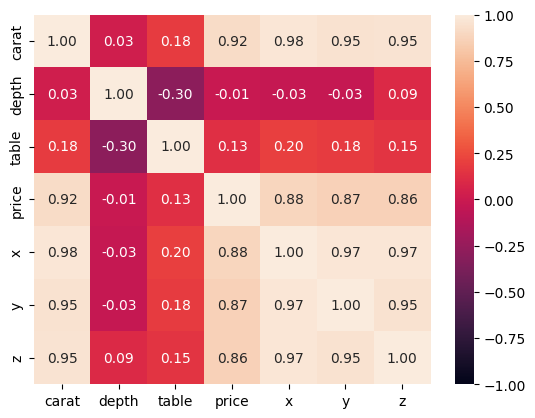

In [341]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', vmin=-1);

__ОТВЕТ:__ видно, что наибольшую корреляцию с целевой переменной имеют признаки, отвечающие за размер бриллианта, а также признак 'carat'.

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [342]:
from sklearn.preprocessing import OneHotEncoder

X_object = df.select_dtypes(include='object')
ohe = OneHotEncoder(sparse_output=False)
X_object_encode = ohe.fit_transform(X_object)
new_columns_names = ohe.get_feature_names_out()
# pd.DataFrame(X_object_encode, columns=new_columns_names)
df = pd.concat([df.select_dtypes(exclude='object'), pd.DataFrame(X_object_encode, columns=new_columns_names)], axis=1)
df.head()

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3. Не забудьте про параметр `stratify`.

Так как параметр stratify не примет просто переменную 'price' из датасета, то надо сначала дискретизировать эту переменную. По графику ниже видим, что цена распределена +- по Пуассону, давайте тогда разобьем весь набор на 20 квантилей с разницей уровней между двумя 0.05 и скажем train_test_split брать равные наборы из каждого подмножества

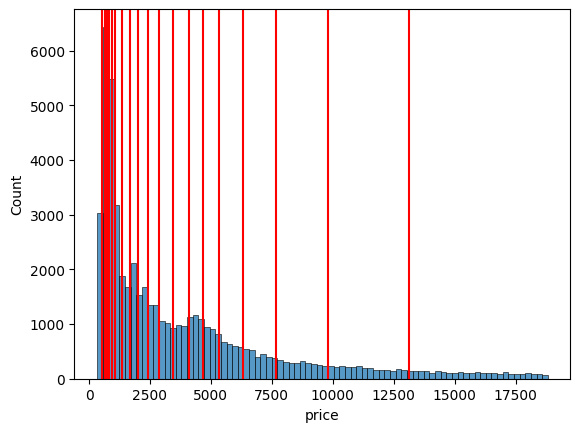

In [343]:
sns.histplot(df['price'])

for quantile in np.arange(0.05, 1, 0.05):
    plt.axvline(x=df['price'].quantile(quantile), color='red')
plt.show()

In [344]:
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = df.drop(columns=['price'])
y = df['price']
y_qcut = pd.cut(y, 25, labels=False)

X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y_qcut)
X_train.shape[0], x_test.shape[0]

(37758, 16182)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [345]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler().set_output(transform='pandas').fit(X_train)
X_train_scale = std.transform(X_train)
x_test_scale = std.transform(x_test)

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [346]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linear_model = LinearRegression().fit(X_train_scale, y_train)

y_test_pred = linear_model.predict(x_test_scale)
y_train_pred = linear_model.predict(X_train_scale)

print(f'MSE на тренировочной выборке {round(mean_squared_error(y_train, y_train_pred), 3)}\nMSE на тестовой выборке {round(mean_squared_error(y_test, y_test_pred), 3)}')

MSE на тренировочной выборке 1274088.399
MSE на тестовой выборке 1283927.171


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [347]:
print(f'Коэффициент перед независимой переменной равен {round(linear_model.intercept_, 2)}')

Коэффициент перед независимой переменной равен 3931.58


In [348]:
print(f'Основные веса перед признаками {np.round(linear_model.coef_, 2)}')

Основные веса перед признаками [ 5316.01   -93.     -58.88 -1159.54    69.31   -40.54  -120.32   -44.45
    49.24    23.67    -3.     207.65   159.61   138.55    61.36  -128.43
  -251.04  -388.44  -475.45   231.5   -146.25  -493.75   204.07   109.79
   252.98   275.61]


In [349]:
coefs = linear_model.coef_
big_coefs = coefs[abs(coefs) >= abs(coefs).mean()]
big_coefs

array([ 5316.008, -1159.54 ,  -475.446,  -493.75 ])

In [350]:
print(f'Вещественные переменные, оценки коэффициентов которых большие: {linear_model.feature_names_in_[np.where(abs(coefs) >= abs(coefs).mean(), True, False)].tolist()}')

Вещественные переменные, оценки коэффициентов которых большие: ['carat', 'x', 'clarity_I1', 'clarity_SI2']


**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [351]:
from sklearn.linear_model import Lasso, Ridge

alpha = 10

linear_lasso = Lasso(alpha=alpha).fit(X_train_scale, y_train)
linear_ridge = Ridge(alpha=alpha).fit(X_train_scale, y_train)
print(f'Веса для Lasso регресси:\n{round(linear_lasso.intercept_, 2), np.round(linear_lasso.coef_, 2)}\nВеса для гребневой регрессии:\n{round(linear_ridge.intercept_, 2), np.round(linear_ridge.coef_, 2)}')


Веса для Lasso регресси:
(np.float64(3931.58), array([4854.08,  -61.2 ,  -45.7 , -642.05,   -0.  ,  -47.81, -124.09,
        -49.02,   33.69,    0.  ,   -7.55,  140.19,   84.86,   63.12,
         -0.  , -175.87, -283.61, -406.52, -493.47,  177.53, -259.65,
       -583.41,   96.15,   -0.  ,  181.82,  192.55]))
Веса для гребневой регрессии:
(np.float64(3931.58), array([ 5278.9 ,   -90.48,   -58.65, -1105.63,    55.58,   -44.68,
        -120.6 ,   -44.5 ,    49.29,    23.54,    -2.77,   207.41,
         159.41,   138.12,    61.13,  -128.22,  -250.45,  -387.68,
        -474.98,   231.85,  -146.8 ,  -493.61,   203.89,   109.63,
         253.43,   275.9 ]))


In [352]:
pd.DataFrame({'Признак': linear_lasso.feature_names_in_, 'Вес в Lasso-регрессии': linear_lasso.coef_})

,Признак,Вес в Lasso-регрессии
0,carat,4854.078393
1,depth,-61.199999
2,table,-45.695137
3,x,-642.050223
4,y,-0.000000
5,z,-47.813766
6,cut_Fair,-124.092093
7,cut_Good,-49.021552
8,cut_Ideal,33.689734
9,cut_Premium,0.000000


__ОТВЕТ:__ совсем незначительно. Видим, что при обучении как Lasso, так и Ridge регрессии веса при признаках получаются примерно одинаковыми. У Ridge регрессии местами даже больше, чем в изначальной регрессии. У Lasso в среднем веса поменьше, но не сильно, также видим проявление свойства "отбора признаков", т.к. один из весов и вовсе занулился.

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

In [353]:
from sklearn.linear_model import Lasso, Ridge

alpha_massive = [0.1, 1, 10, 100, 200]
norm_lasso = []
norm_ridge = []


for alpha in alpha_massive:
    lasso_model = Lasso(alpha=alpha).fit(X_train_scale, y_train)
    ridge_model = Ridge(alpha=alpha).fit(X_train_scale, y_train)
    
    norm_lasso.append(np.linalg.norm(lasso_model.coef_))
    norm_ridge.append(np.linalg.norm(ridge_model.coef_))

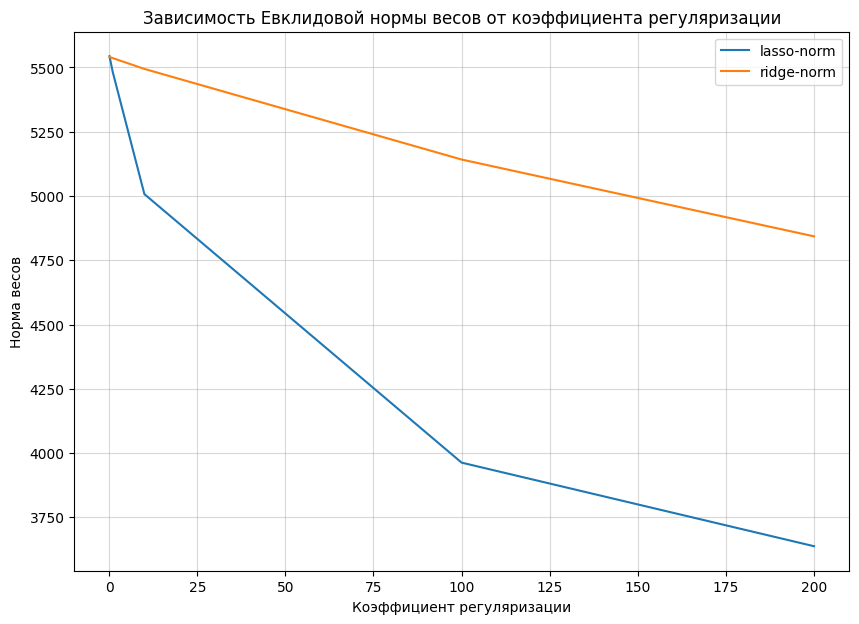

In [354]:
plt.figure(figsize=(10, 7))

plt.plot(alpha_massive, norm_lasso, label='lasso-norm')
plt.plot(alpha_massive, norm_ridge, label='ridge-norm')

plt.title('Зависимость Евклидовой нормы весов от коэффициента регуляризации')
plt.xlabel('Коэффициент регуляризации')
plt.ylabel('Норма весов')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

__ОТВЕТ:__ сильнее и быстрее норму снижает Lasso-регуляризация. А для отбора признаков Lasso-регрессию используют из-за её способности занулять веса у фактически ненужных признаков, что помогает выбрать те признаки, которые наилучшим образом способствуют построению модели регрессии.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [355]:
from sklearn.linear_model import LassoCV
np.set_printoptions(suppress=True, precision=None)

linear_lassoCV = LassoCV(cv=5, alphas=[*alpha_massive]).fit(X_train_scale, y_train)
mse_matrix = linear_lassoCV.mse_path_
alpha_order = linear_lassoCV.alphas_
mean_mse_along_1 = mse_matrix.mean(axis=1)
best_alpha = linear_lassoCV.alpha_
print(f'1) Усредненные значения ошибок {mean_mse_along_1}\n2) Порядок использования \u03B1: {', '.join(map(str, alpha_order))}\n\
3) Лучшее \u03B1 по качеству - {linear_lassoCV.alpha_}')

1) Усредненные значения ошибок [1946890.42  1528585.656 1288850.79  1278137.687 1278910.531]
2) Порядок использования α: 200.0, 100.0, 10.0, 1.0, 0.1
3) Лучшее α по качеству - 1.0


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [356]:
the_best_alpha = 1

best_lasso = Lasso(alpha=the_best_alpha).fit(X_train_scale, y_train)
massive = pd.DataFrame({'Признак': X_train_scale.columns, 'коэффициент': best_lasso.coef_})
display(massive)
print(f'Бесполезные признаки при Lasso регрессии:\n{massive.loc[abs(massive['коэффициент']) == 0, 'Признак']}')

,Признак,коэффициент
0,carat,5272.077211
1,depth,-90.599963
2,table,-57.809455
3,x,-1050.840842
4,y,0.000000
5,z,-38.141728
6,cut_Fair,-129.169000
7,cut_Good,-58.170501
8,cut_Ideal,24.754957
9,cut_Premium,0.000000


Бесполезные признаки при Lasso регрессии:
4               y
9     cut_Premium
14        color_G
23    clarity_VS2
Name: Признак, dtype: object


__ОТВЕТ:__ наиболее информативных можно выделить два: 'carat' и 'x'. Почему? Ну насколько я понял из описания датасета, 'carat' - это непосредственно вес самого бриллианта, поэтому даже если бриллиант не лучшего качества (признаки 'cut', 'color'), но при этом весь очень много, то этот вес затмевает собой качество. Ведь лучше бриллиант плохого качества, чем идеальный булыжник, неправда ли?

Почему длина ('x') является такой информативной и причем в отрицательную сторону я, честно говоря, не знаю. Типо чем длиннее бриллиант, чем он более плоский, тем он более некрасивый, его сложнее обрабатывать и он более 'неприродный', может так?

Но здесь сразу возникает обратная сторона: почему тогда 'y' (ширина) неинформативный? хз короче.
Все остальные признаки категориальные, у них нулевой вес, как мне кажется, это чисто формальность для решения проблемы мультиколлинеарности, не думаю что там очень значимый смысл за этим. Если изначально про кодировании через OneHotEncoder дропать по одному столбцу, то проблема наполовину уже уйдёт сразу.

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [357]:
from sklearn.metrics import mean_squared_error
y_best_lasso = best_lasso.predict(x_test_scale)
print(f'MSE для нашей топовой Лассо регресии составляет всего лишь {mean_squared_error(y_test, y_best_lasso)} против {1283927} у обычной. ВЫбираем конечно же топовую лассов')

MSE для нашей топовой Лассо регресии составляет всего лишь 1283576.4923630797 против 1283927 у обычной. ВЫбираем конечно же топовую лассов


Почему лассо круче? Потому что есть регуляризация и это позволяет нам не переобучаться и лучше адаптироваться к новым данным, запрещая большие веса, чего нет у обычной модельки.